In [1]:

# Import Libraries


from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from scipy.optimize import curve_fit

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:

# Load Data


btc_path = Path.home() / ".stacksats" / "data" / "bitcoin_analytics.parquet"

df = pl.read_parquet(btc_path).to_pandas()

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date").sort_index()

df = df.replace([np.inf, -np.inf], np.nan)

# Use only 2018-01-01 to 2023-12-31
df = df.loc["2018-01-01":"2023-12-31"].copy()

df.head()

,price_usd,mvrv,adjusted_sopr,adjusted_sopr_7d_ema,realized_cap_growth_rate,market_cap_growth_rate
date,,,,,,
2018-01-01,13466.31,2.697882,1.001030,1.037615,1102.8148,1315.7910
2018-01-02,14888.11,2.944071,1.071507,1.046088,1104.3805,1429.6768
2018-01-03,15098.14,3.001065,1.055439,1.048426,1105.2825,1438.3800
2018-01-04,15144.99,2.985702,1.064714,1.052498,1101.5583,1297.2197
2018-01-05,16960.01,3.285019,1.107543,1.066259,1104.8623,1658.4019


In [3]:

# Select Initial Columns


candidate_cols = [
    "price_usd",
    "mvrv",
    "adjusted_sopr",
    "adjusted_sopr_7d_ema",
    "realized_cap_growth_rate",
    "market_cap_growth_rate"
]

available_cols = [col for col in candidate_cols if col in df.columns]

ts = df[available_cols].copy()

ts = ts.dropna(how="all")

ts.head()

,price_usd,mvrv,adjusted_sopr,adjusted_sopr_7d_ema,realized_cap_growth_rate,market_cap_growth_rate
date,,,,,,
2018-01-01,13466.31,2.697882,1.001030,1.037615,1102.8148,1315.7910
2018-01-02,14888.11,2.944071,1.071507,1.046088,1104.3805,1429.6768
2018-01-03,15098.14,3.001065,1.055439,1.048426,1105.2825,1438.3800
2018-01-04,15144.99,2.985702,1.064714,1.052498,1101.5583,1297.2197
2018-01-05,16960.01,3.285019,1.107543,1.066259,1104.8623,1658.4019


In [4]:

# Check Missing Values


ts.isna().mean().sort_values(ascending=False)

price_usd                   0.0
mvrv                        0.0
adjusted_sopr               0.0
adjusted_sopr_7d_ema        0.0
realized_cap_growth_rate    0.0
market_cap_growth_rate      0.0
dtype: float64

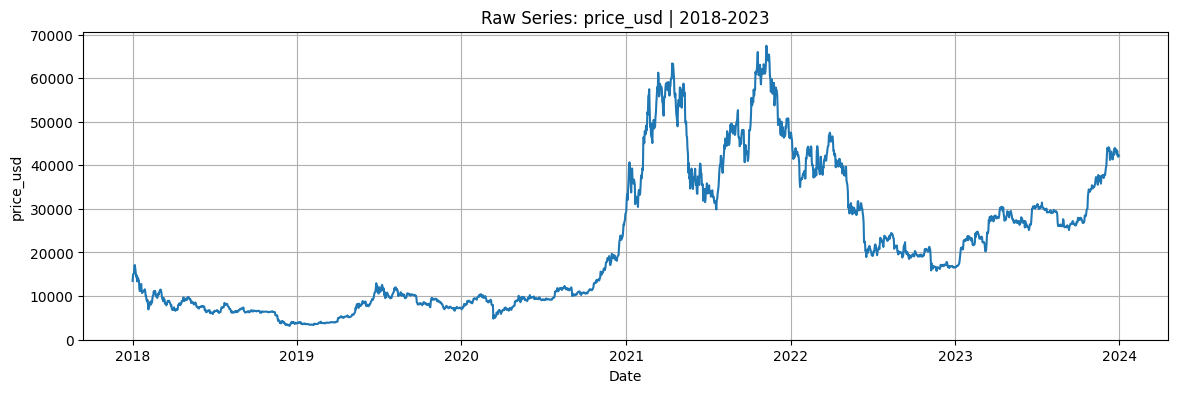

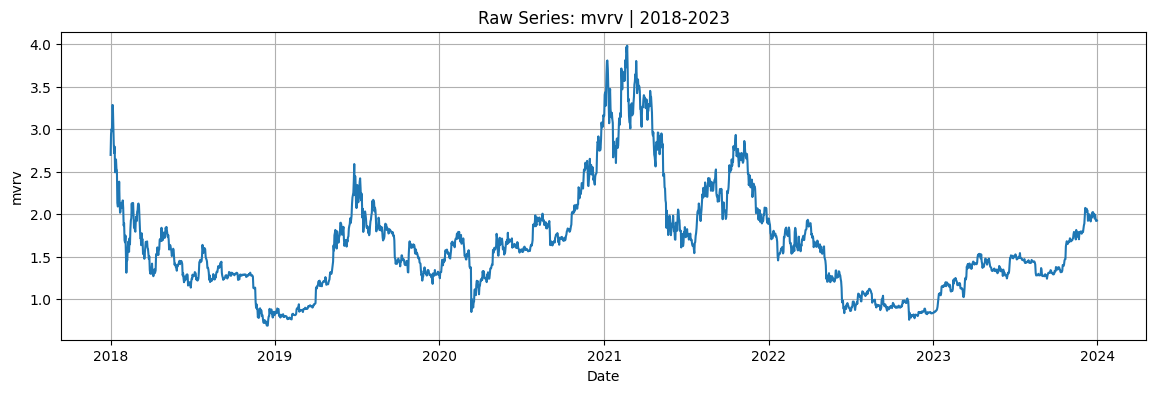

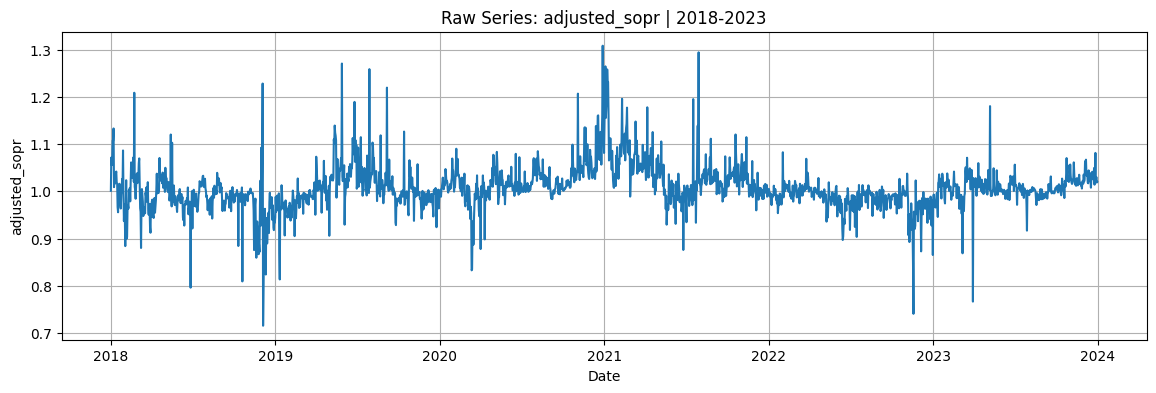

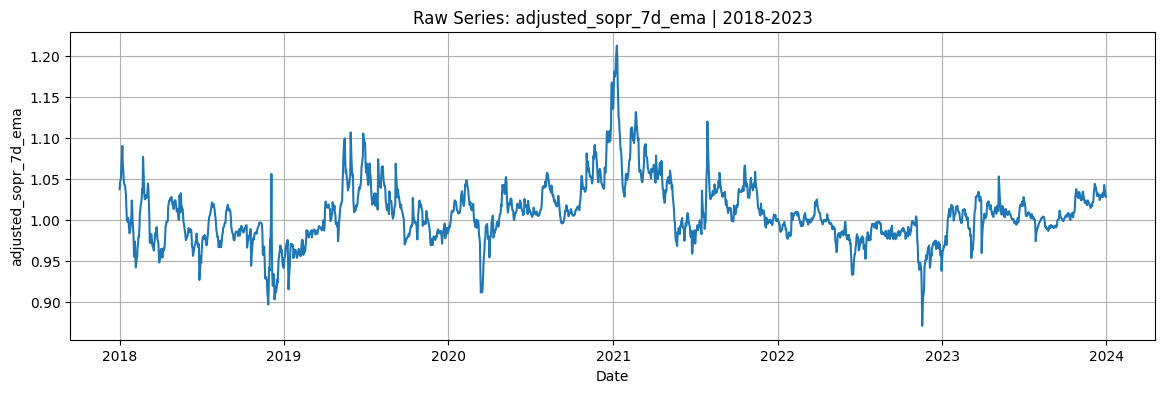

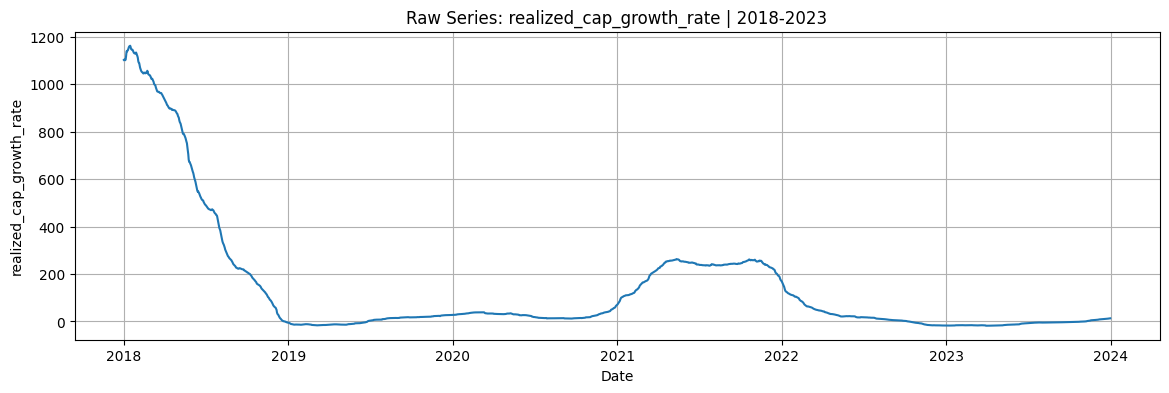

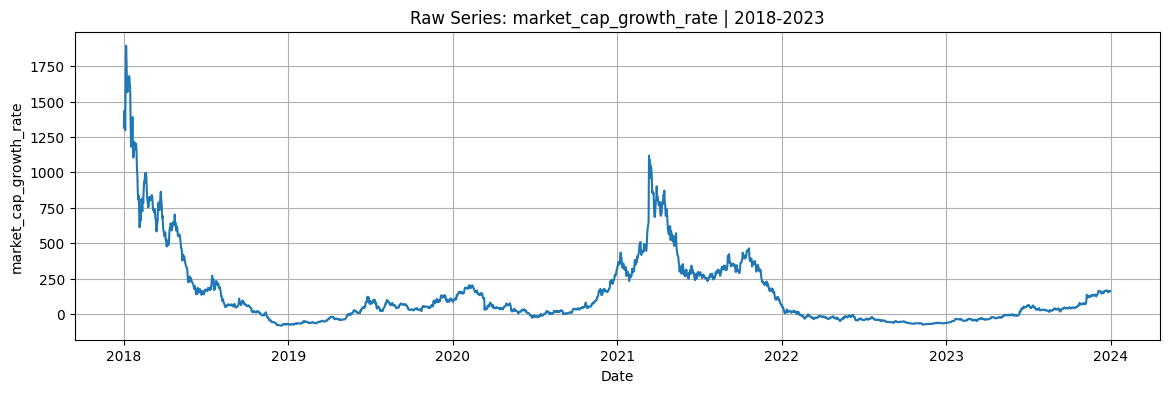

In [5]:

# Plot Raw Series


for col in available_cols:
    plt.figure(figsize=(14, 4))
    plt.plot(ts.index, ts[col])
    plt.title(f"Raw Series: {col} | 2018-2023")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

In [6]:

# Seasonal Strength Function


def seasonal_strength(stl_result):
    """
    Seasonal strength:
    1 - Var(Residual) / Var(Seasonal + Residual)

    Higher value means stronger seasonality.
    """

    seasonal = stl_result.seasonal.dropna()
    resid = stl_result.resid.dropna()

    common_index = seasonal.index.intersection(resid.index)

    seasonal = seasonal.loc[common_index]
    resid = resid.loc[common_index]

    denominator = np.var(seasonal + resid)

    if denominator == 0:
        return np.nan

    strength = 1 - (np.var(resid) / denominator)

    return max(0, strength)

In [7]:

# Check Seasonality Across Multiple Periods


periods_to_check = [7, 30, 90, 182, 365]

seasonality_results = []

for col in available_cols:
    s = ts[col].dropna()

    for period in periods_to_check:
        if len(s) < 2 * period:
            continue

        try:
            stl_result = STL(s, period=period, robust=True).fit()
            strength = seasonal_strength(stl_result)

            seasonality_results.append({
                "series": col,
                "period": period,
                "seasonal_strength": strength
            })

        except Exception as e:
            print(f"Could not process {col} with period={period}: {e}")

seasonality_summary_df = pd.DataFrame(seasonality_results)

seasonality_summary_df = seasonality_summary_df.sort_values(
    "seasonal_strength",
    ascending=False
).reset_index(drop=True)

seasonality_summary_df

,series,period,seasonal_strength
0,adjusted_sopr_7d_ema,182,0.093844
1,adjusted_sopr_7d_ema,365,0.092275
2,adjusted_sopr,365,0.086815
3,price_usd,182,0.082032
4,adjusted_sopr,90,0.070286
5,adjusted_sopr,182,0.065632
6,adjusted_sopr_7d_ema,90,0.041952
7,adjusted_sopr,30,0.031834
8,mvrv,182,0.028529
9,adjusted_sopr,7,0.023811


In [8]:

# Add Interpretation Column


def interpret_seasonality_strength(x):
    if pd.isna(x):
        return "unknown"
    elif x < 0.10:
        return "weak"
    elif x < 0.30:
        return "mild"
    elif x < 0.60:
        return "moderate"
    else:
        return "strong"

seasonality_summary_df["seasonality_level"] = seasonality_summary_df[
    "seasonal_strength"
].apply(interpret_seasonality_strength)

seasonality_summary_df

,series,period,seasonal_strength,seasonality_level
0,adjusted_sopr_7d_ema,182,0.093844,weak
1,adjusted_sopr_7d_ema,365,0.092275,weak
2,adjusted_sopr,365,0.086815,weak
3,price_usd,182,0.082032,weak
4,adjusted_sopr,90,0.070286,weak
5,adjusted_sopr,182,0.065632,weak
6,adjusted_sopr_7d_ema,90,0.041952,weak
7,adjusted_sopr,30,0.031834,weak
8,mvrv,182,0.028529,weak
9,adjusted_sopr,7,0.023811,weak


In [9]:

# Define Simple Sine Function

def sine_func(t, amplitude, period, phase_shift, vertical_shift):
    """
    Simple sine function.

    amplitude controls height of the wave.
    period controls cycle length.
    phase_shift shifts the wave left/right.
    vertical_shift shifts the wave up/down.
    """

    return amplitude * np.sin((2 * np.pi * t / period) + phase_shift) + vertical_shift

In [10]:

# Fit Sine to STL Seasonal Component


def fit_sine_to_seasonal(series, stl_period=30, initial_fit_period=30, show_plot=False):
    s = series.dropna()

    if len(s) < 2 * stl_period:
        return None

    try:
        # STL decomposition
        stl_result = STL(s, period=stl_period, robust=True).fit()
        seasonal = stl_result.seasonal.dropna()

        # Numeric time index
        t = np.arange(len(seasonal))

        # Initial guesses
        initial_amplitude = (seasonal.max() - seasonal.min()) / 2
        initial_period = initial_fit_period
        initial_phase_shift = 0
        initial_vertical_shift = seasonal.mean()

        initial_guess = [
            initial_amplitude,
            initial_period,
            initial_phase_shift,
            initial_vertical_shift
        ]

        # Fit simple sine curve
        params, _ = curve_fit(
            sine_func,
            t,
            seasonal.values,
            p0=initial_guess,
            maxfev=50000
        )

        fitted_values = sine_func(t, *params)

        # Evaluation metrics
        rmse = np.sqrt(np.mean((seasonal.values - fitted_values) ** 2))
        mae = np.mean(np.abs(seasonal.values - fitted_values))

        # Calculate the residual sum of squares.
        # This measures how much error is left between the actual STL seasonal component
        # and the fitted curve.
        ss_res = np.sum((seasonal.values - fitted_values) ** 2)

        # Calculate the total sum of squares.
        # This measures the total variation in the actual STL seasonal component
        # around its own mean.
        ss_tot = np.sum((seasonal.values - np.mean(seasonal.values)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        if show_plot:
            plt.figure(figsize=(14, 5))
            plt.plot(seasonal.index, seasonal.values, label="STL Seasonal Component")
            plt.plot(seasonal.index, fitted_values, label="Fitted Sine Curve")
            plt.title(f"Sine Fit on Seasonal Component: {series.name} | Period={stl_period}")
            plt.xlabel("Date")
            plt.ylabel("Seasonal Component")
            plt.legend()
            plt.grid(True)
            plt.show()

        return {
            "series": series.name,
            "stl_period": stl_period,
            "fitted_amplitude": params[0],
            "fitted_period": params[1],
            "fitted_phase_shift": params[2],
            "fitted_vertical_shift": params[3],
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "r2_percent": r2 * 100
        }

    except Exception as e:
        print(f"Could not fit sine for {series.name}, period={stl_period}: {e}")
        return None

In [11]:

# Run Sine Fit for All Seasonality Results


sine_results = []

for _, row in seasonality_summary_df.iterrows():
    col = row["series"]
    period = int(row["period"])
    strength = row["seasonal_strength"]

    result = fit_sine_to_seasonal(
        ts[col],
        stl_period=period,
        initial_fit_period=period,
        show_plot=False
    )

    if result is not None:
        result["seasonal_strength"] = strength
        result["seasonality_level"] = row["seasonality_level"]
        sine_results.append(result)

sine_results_df = pd.DataFrame(sine_results)

if sine_results_df.empty:
    print("No sine-fit results found.")
else:
    sine_results_df = sine_results_df.sort_values(
        "r2",
        ascending=False
    ).reset_index(drop=True)

sine_results_df

,series,stl_period,fitted_amplitude,fitted_period,fitted_phase_shift,fitted_vertical_shift,rmse,mae,r2,r2_percent,seasonal_strength,seasonality_level
0,realized_cap_growth_rate,365,152.440917,382.220716,0.496526,13.908775,112.199063,86.998855,0.485066,48.506630,0.000000,weak
1,realized_cap_growth_rate,182,17.573598,177.730793,-2.164055,0.287535,16.983872,12.336159,0.350218,35.021841,0.000000,weak
2,market_cap_growth_rate,365,132.151388,355.592358,0.447619,12.523252,134.092382,90.533740,0.328227,32.822668,0.000000,weak
3,adjusted_sopr_7d_ema,90,-0.009628,90.771600,1.740991,0.000141,0.011097,0.007434,0.273890,27.388994,0.041952,weak
4,price_usd,182,-1869.748966,199.395288,5.264286,62.872378,3011.669047,2067.600719,0.161500,16.149996,0.082032,weak
5,adjusted_sopr,90,-0.007702,90.733756,1.963964,0.000169,0.014058,0.010087,0.130445,13.044452,0.070286,weak
6,realized_cap_growth_rate,90,4.227064,88.178273,-1.214577,0.133645,7.907211,4.541250,0.124472,12.447183,0.000000,weak
7,mvrv,90,-0.060227,91.618420,2.179151,0.001012,0.119602,0.079609,0.112239,11.223944,0.000000,weak
8,mvrv,365,0.103876,360.772204,1.113743,0.020424,0.245316,0.167336,0.083034,8.303367,0.015339,weak
9,price_usd,90,834.431773,90.023546,-1.025767,18.735335,1956.032763,1229.286871,0.082976,8.297650,0.000000,weak


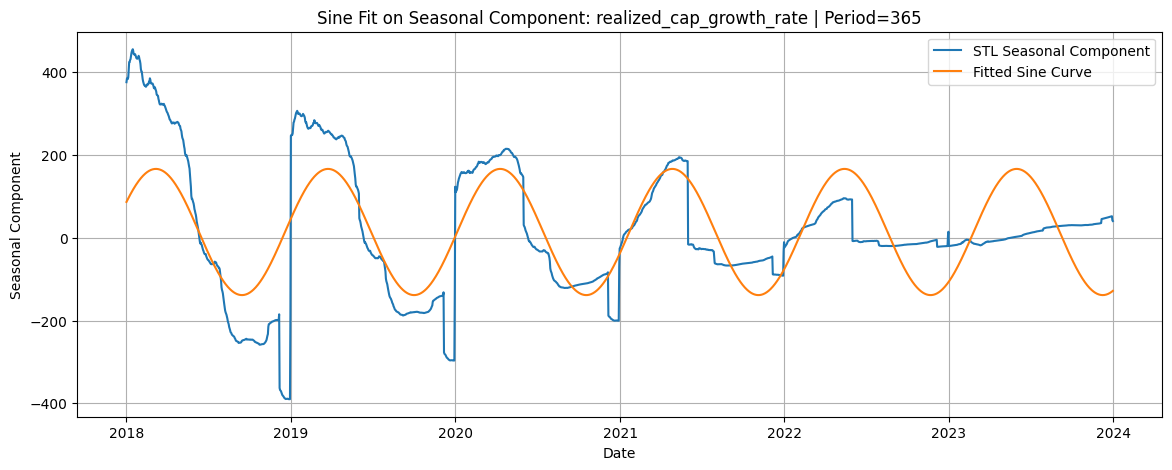

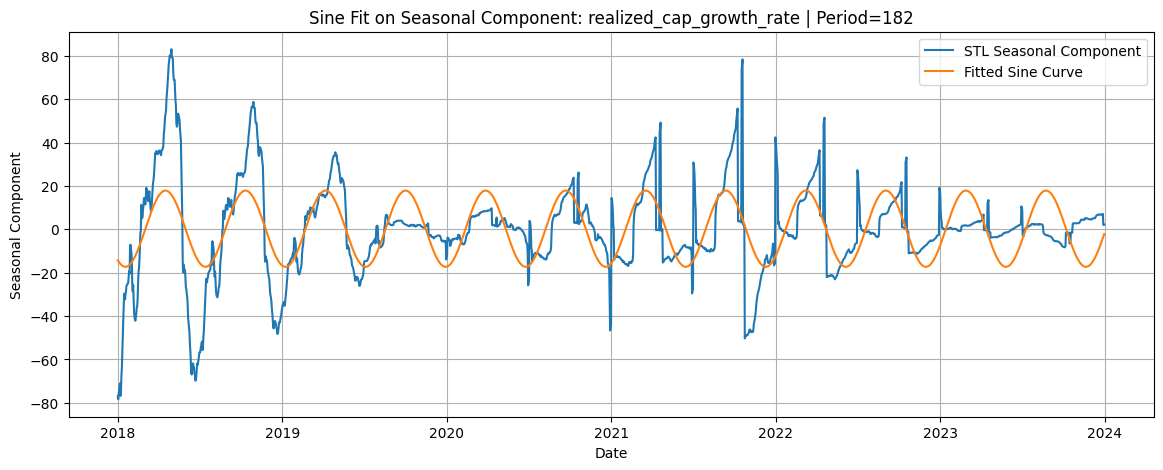

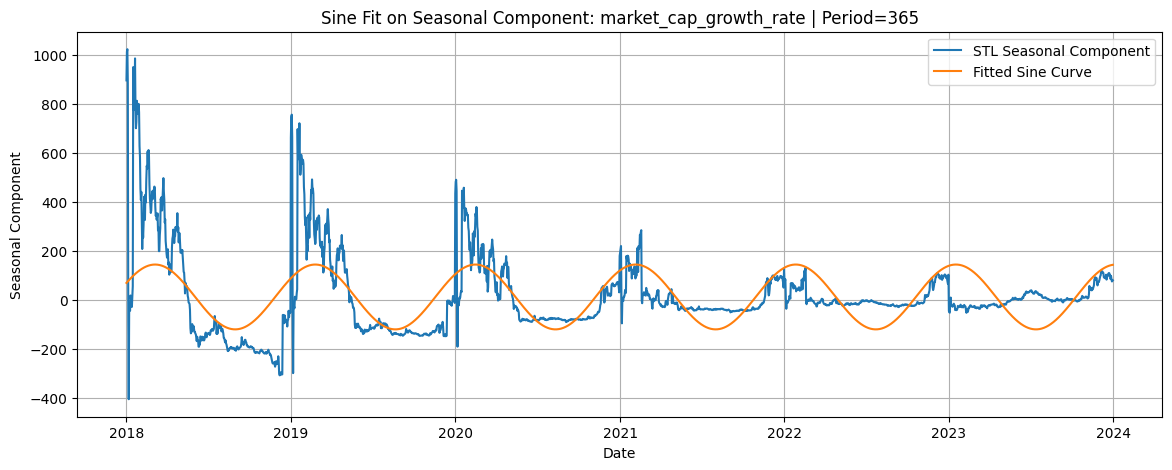

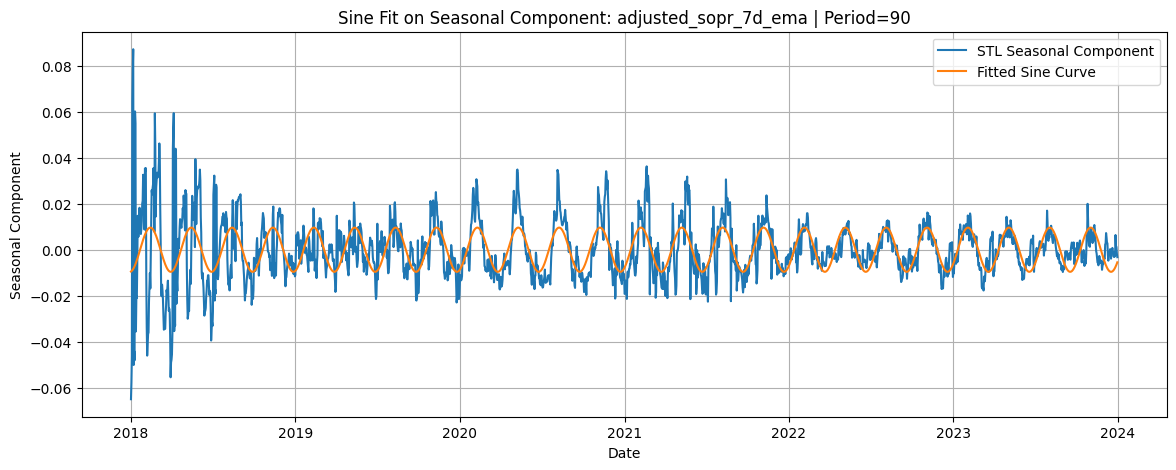

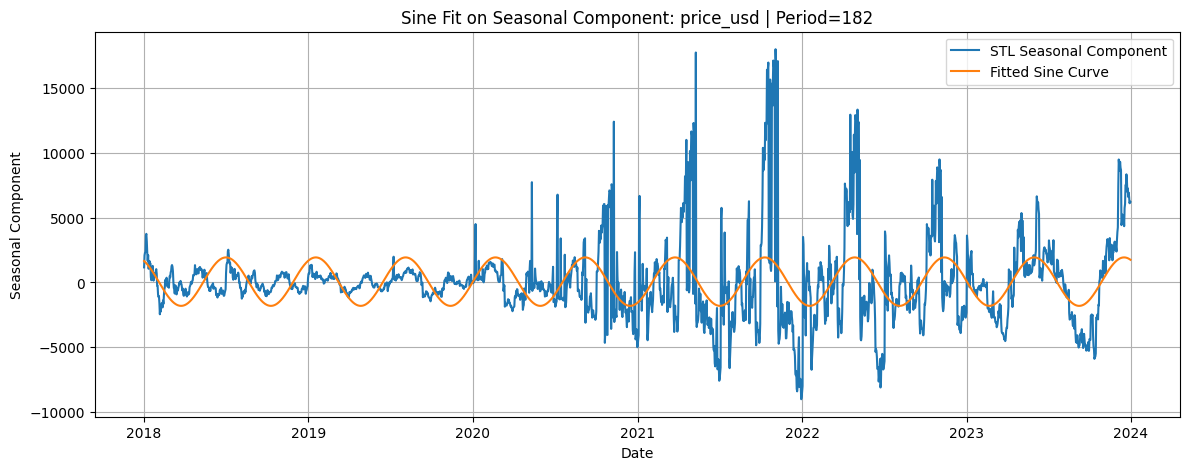

In [12]:

# Plot Top 5 Sine Fits


if not sine_results_df.empty:
    top_5_sine = sine_results_df.head(5)

    for _, row in top_5_sine.iterrows():
        col = row["series"]
        period = int(row["stl_period"])

        fit_sine_to_seasonal(
            ts[col],
            stl_period=period,
            initial_fit_period=period,
            show_plot=True
        )

In [13]:
# Define sin square(x)

def sin_squared_func(t, amplitude, period, phase_shift, vertical_shift):
    """
    Sine-squared function.

    amplitude controls the height of the wave.
    period controls the cycle length.
    phase_shift shifts the wave left/right.
    vertical_shift shifts the wave up/down.
    """

    return amplitude * (
        np.sin((2 * np.pi * t / period) + phase_shift) ** 2
    ) + vertical_shift

In [14]:

# Fit sin square(x) to STL Seasonal Component

def fit_sin_squared_to_seasonal(series, stl_period=30, initial_fit_period=30, show_plot=False):
    s = series.dropna()

    if len(s) < 2 * stl_period:
        return None

    try:
        # STL decomposition
        stl_result = STL(s, period=stl_period, robust=True).fit()
        seasonal = stl_result.seasonal.dropna()

        # Numeric time index
        t = np.arange(len(seasonal))

        # Initial guesses
        initial_amplitude = seasonal.max() - seasonal.min()
        initial_period = initial_fit_period
        initial_phase_shift = 0
        initial_vertical_shift = seasonal.min()

        initial_guess = [
            initial_amplitude,
            initial_period,
            initial_phase_shift,
            initial_vertical_shift
        ]

        # Fit sin square curve
        params, _ = curve_fit(
            sin_squared_func,
            t,
            seasonal.values,
            p0=initial_guess,
            maxfev=50000
        )

        fitted_values = sin_squared_func(t, *params)

        # Evaluation metrics
        rmse = np.sqrt(np.mean((seasonal.values - fitted_values) ** 2))
        mae = np.mean(np.abs(seasonal.values - fitted_values))

        ss_res = np.sum((seasonal.values - fitted_values) ** 2)
        ss_tot = np.sum((seasonal.values - np.mean(seasonal.values)) ** 2)
        r2 = 1 - (ss_res / ss_tot)

        if show_plot:
            plt.figure(figsize=(14, 5))
            plt.plot(seasonal.index, seasonal.values, label="STL Seasonal Component")
            plt.plot(seasonal.index, fitted_values, label="Fitted sin square(x) Curve")
            plt.title(f"sin square(x) Fit on Seasonal Component: {series.name} | Period={stl_period}")
            plt.xlabel("Date")
            plt.ylabel("Seasonal Component")
            plt.legend()
            plt.grid(True)
            plt.show()

        return {
            "series": series.name,
            "stl_period": stl_period,
            "fitted_amplitude": params[0],
            "fitted_period": params[1],
            "fitted_phase_shift": params[2],
            "fitted_vertical_shift": params[3],
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "r2_percent": r2 * 100
        }

    except Exception as e:
        print(f"Could not fit sin square(x) for {series.name}, period={stl_period}: {e}")
        return None

In [15]:
# Run sin square(x) Fit for All Seasonality Results

sin_squared_results = []

for _, row in seasonality_summary_df.iterrows():
    col = row["series"]
    period = int(row["period"])
    strength = row["seasonal_strength"]

    result = fit_sin_squared_to_seasonal(
        ts[col],
        stl_period=period,
        initial_fit_period=period,
        show_plot=False
    )

    if result is not None:
        # Reuse existing seasonality strength and interpretation
        result["seasonal_strength"] = strength
        result["seasonality_level"] = row["seasonality_level"]

        sin_squared_results.append(result)

sin_squared_results_df = pd.DataFrame(sin_squared_results)

if sin_squared_results_df.empty:
    print("No sin square(x) fit results found.")
else:
    sin_squared_results_df = sin_squared_results_df.sort_values(
        "r2",
        ascending=False
    ).reset_index(drop=True)

sin_squared_results_df

,series,stl_period,fitted_amplitude,fitted_period,fitted_phase_shift,fitted_vertical_shift,rmse,mae,r2,r2_percent,seasonal_strength,seasonality_level
0,price_usd,365,-4648.958885,357.528210,-0.336265,2371.576765,2904.868249,2035.178638,0.244704,24.470408,0.000000,weak
1,adjusted_sopr_7d_ema,182,0.018442,183.259319,0.544551,-0.008878,0.013093,0.009349,0.198692,19.869240,0.093844,weak
2,mvrv,182,0.186255,186.336524,0.932106,-0.088239,0.162143,0.113607,0.141478,14.147763,0.028529,weak
3,mvrv,365,-0.228446,352.492855,-0.605474,0.133017,0.243065,0.165269,0.099790,9.978996,0.015339,weak
4,price_usd,182,2686.165369,182.561139,0.611288,-1281.909771,3148.850397,2061.011132,0.083373,8.337299,0.082032,weak
5,market_cap_growth_rate,365,132.502175,352.877659,-2.571808,-52.284596,156.751108,102.603346,0.082015,8.201459,0.000000,weak
6,adjusted_sopr_7d_ema,365,0.015285,385.273818,1.042921,-0.006692,0.018539,0.013692,0.078922,7.892181,0.092275,weak
7,realized_cap_growth_rate,182,-15.799150,177.130405,-1.354895,7.764005,20.318878,14.936815,0.069978,6.997755,0.000000,weak
8,adjusted_sopr,182,0.013154,182.503151,0.491958,-0.006327,0.017244,0.011746,0.067792,6.779209,0.065632,weak
9,market_cap_growth_rate,182,41.119520,185.758303,1.063557,-18.342663,62.695132,42.673933,0.051025,5.102502,0.000000,weak


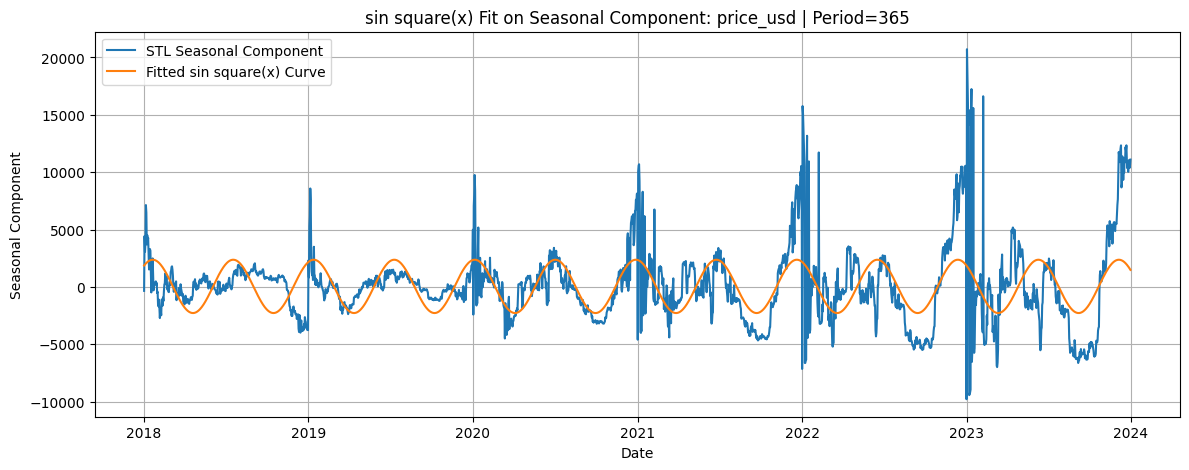

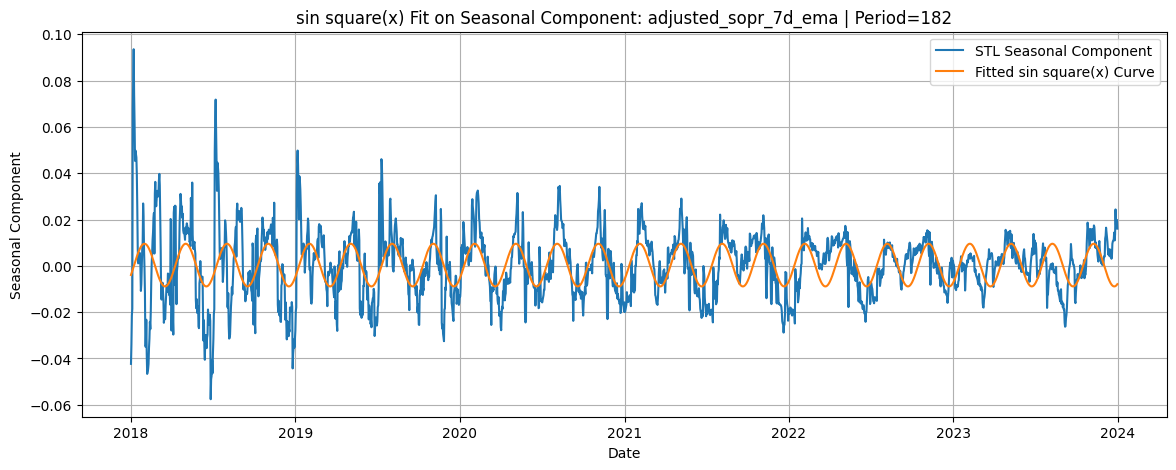

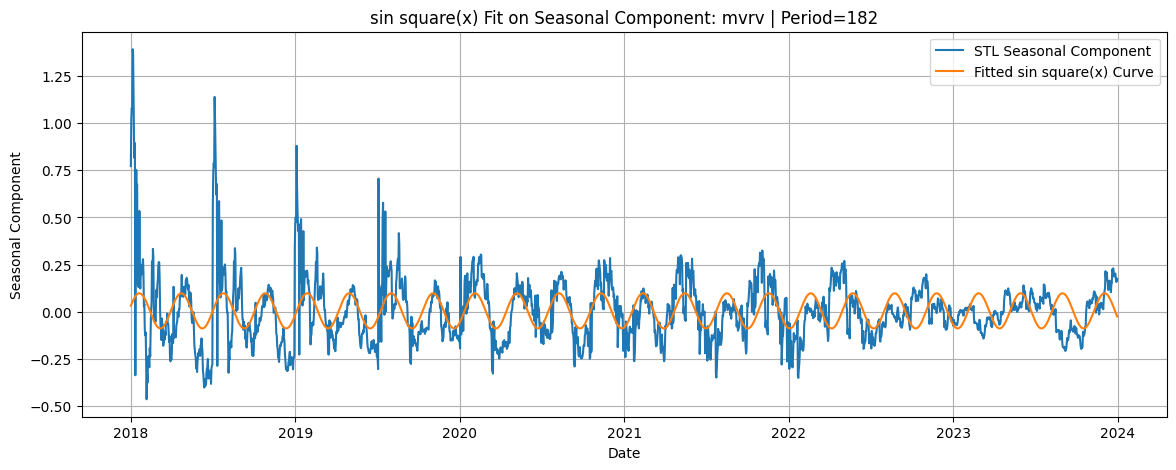

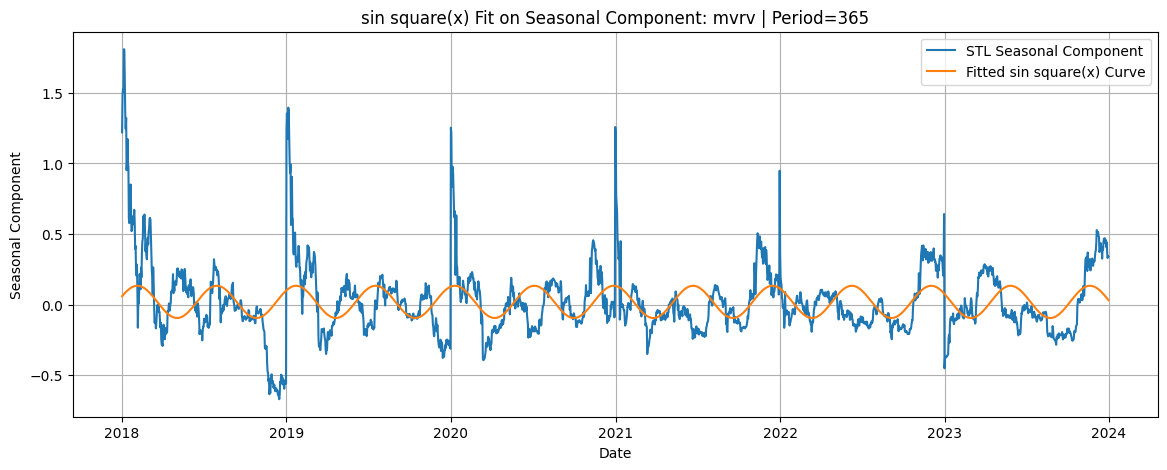

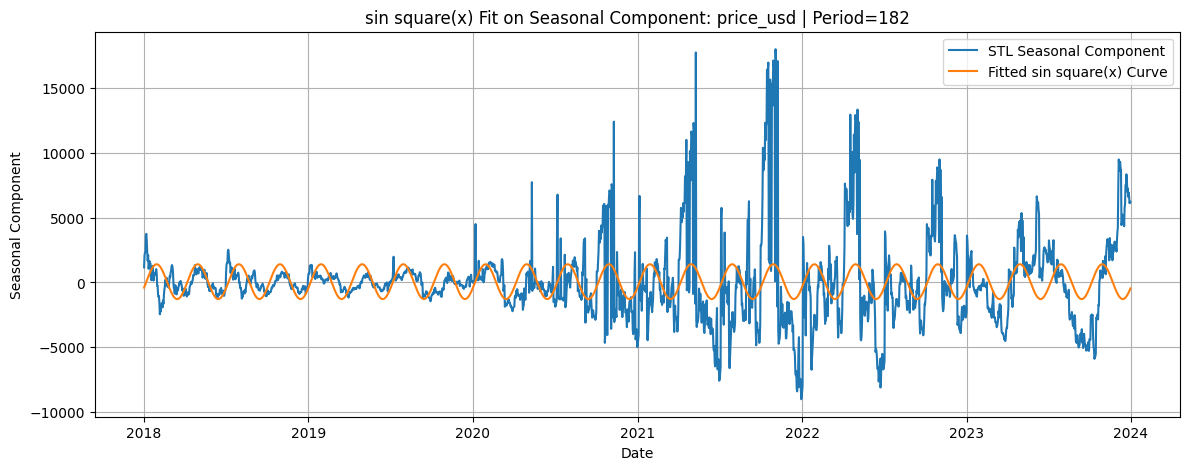

In [16]:
# Plot Top 5 sin square(x) Fits

if not sin_squared_results_df.empty:
    top_5_sin_squared = sin_squared_results_df.head(5)

    for _, row in top_5_sin_squared.iterrows():
        col = row["series"]
        period = int(row["stl_period"])

        fit_sin_squared_to_seasonal(
            ts[col],
            stl_period=period,
            initial_fit_period=period,
            show_plot=True
        )